In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, regexp_extract, trim,
lit, expr, regexp_replace, explode, lower, split, size
from pyspark.ml.feature import Tokenizer, StopWordsRemover
from os import truncate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


spark = (SparkSession.builder
         .appName("Books EDA")
         .config("spark.driver.memory", "8g")
         .getOrCreate())

ratings_df = spark.read.parquet(
    "/content/drive/MyDrive/Data_mining/clean/ratings_clean.parquet"
)

books_df = spark.read.parquet(
    "/content/drive/MyDrive/Data_mining/clean/books_clean.parquet"
)


In [ ]:
books_df.show(5, truncate=False)
ratings_df.show(5, truncate=False)

+-------------------------------------------------------+------------------------+--------------------------+-------------+-----------------------------+
|Title                                                  |authors                 |publisher                 |publishedDate|categories                   |
+-------------------------------------------------------+------------------------+--------------------------+-------------+-----------------------------+
|Its Only Art If Its Well Hung!                         |['Julie Strain']        |NULL                      |1996         |['Comics & Graphic Novels']  |
|Wonderful Worship in Smaller Churches                  |['David R. Ray']        |NULL                      |2000         |['Religion']                 |
|Whispers of the Wicked Saints                          |['Veronica Haddon']     |iUniverse                 |2005-02      |['Fiction']                  |
|The Church of Christ: A Biblical Ecclesiology for Today|['Everett Ferguson'

In [ ]:
rating_dist = (
    ratings_df
    .groupBy("review/score")
    .agg(count("*").alias("count"))
    .orderBy("review/score")
)

rating_dist.show()

+------------+-------+
|review/score|  count|
+------------+-------+
|         1.0| 200992|
|         2.0| 150438|
|         3.0| 252930|
|         4.0| 581698|
|         5.0|1795611|
+------------+-------+



/tmp/ipython-input-3440880455.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


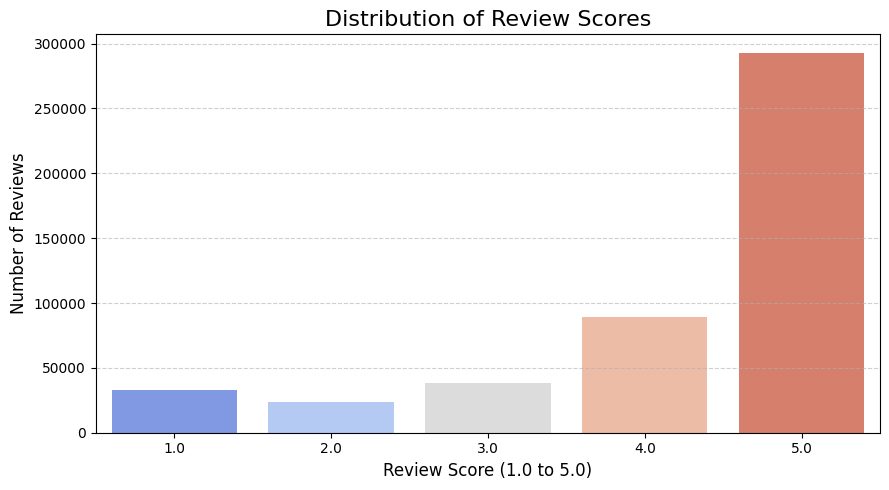

In [ ]:
ratings_df = ratings_df.withColumn(
    "Clean_Score",
    expr("try_cast(`review/score` as float)")
).withColumn(
    "Clean_Score",
    when(
        (col("Clean_Score") >= 1) & (col("Clean_Score") <= 5),
        col("Clean_Score")
    ).otherwise(lit(None))
)

ratings_df_clean = ratings_df.filter(col("Clean_Score").isNotNull())

rating_dist = (
    ratings_df_clean
    .groupBy("Clean_Score")
    .agg(count("*").alias("count"))
    .orderBy("Clean_Score")
)

rating_dist_pd = rating_dist.toPandas()
plt.figure(figsize=(9,5))

sns.barplot(
    x="Clean_Score",
    y="count",
    data=rating_dist_pd,
    palette="coolwarm"
)

plt.title("Distribution of Review Scores", fontsize=16)
plt.xlabel("Review Score (1.0 to 5.0)", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


The distribution of review scores is heavily skewed toward higher ratings, with scores of 4 and 5 accounting for the majority of reviews. This positive bias suggests that users are more likely to leave reviews for books they enjoyed, which should be considered when interpreting subsequent analyses.

/tmp/ipython-input-2997250732.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


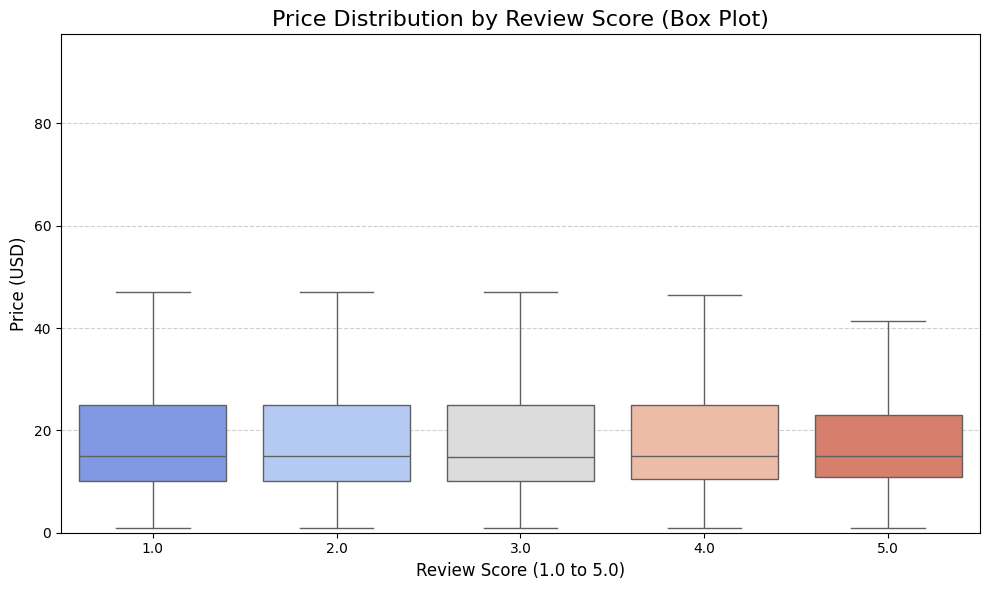

In [ ]:
df_analysis = ratings_df.withColumn(
    "Clean_Price",
    regexp_replace(col("Price"), "[$,]", "").cast("float")
)

df_analysis = df_analysis.withColumn(
    "Clean_Score",
    expr("try_cast(`review/score` as float)")
)

df_clean_for_plot = df_analysis.filter(
    (col("Clean_Price").isNotNull()) &
    (col("Clean_Price") > 0) &
    (col("Clean_Score").isNotNull()) &
    (col("Clean_Score") >= 1) &
    (col("Clean_Score") <= 5)
)

SAMPLE_SIZE = 100_000
sampling_fraction = SAMPLE_SIZE / df_clean_for_plot.count()

df_sample_pd = (
    df_clean_for_plot
    .sample(fraction=sampling_fraction, seed=42)
    .select("Clean_Score", "Clean_Price")
    .toPandas()
)


plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Clean_Score",
    y="Clean_Price",
    data=df_sample_pd,
    palette="coolwarm",
    showfliers=False
)

plt.ylim(0, df_sample_pd["Clean_Price"].quantile(0.98))

plt.title("Price Distribution by Review Score (Box Plot)", fontsize=16)
plt.xlabel("Review Score (1.0 to 5.0)", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
book_review_counts = (
    ratings_df
    .groupBy("Title")
    .agg(count("*").alias("num_reviews"))
    .orderBy(col("num_reviews").desc())
)
top_books = book_review_counts.limit(10)
top_books.show(truncate=False)
top_books_pd = top_books.toPandas()


+---------------------------------------------------------------------------------------------------------------------------------------------------+-----------+
|Title                                                                                                                                              |num_reviews|
+---------------------------------------------------------------------------------------------------------------------------------------------------+-----------+
|Hannibal                                                                                                                                           |2788       |
|Wuthering Heights                                                                                                                                  |2134       |
|Wizard's First Rule (Sword of Truth, Book 1)                                                                                                       |1801       |
|Eldest (Inheritance, Book 2

/tmp/ipython-input-2459803546.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


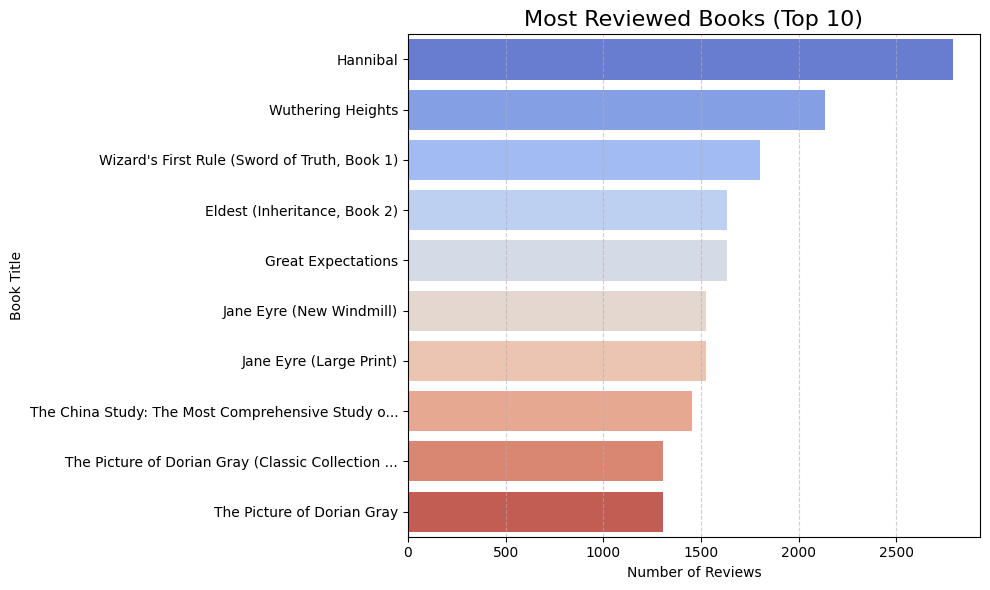

In [ ]:
top_books_pd["Title_short"] = top_books_pd["Title"].apply(
    lambda x: x if len(x) <= 50 else x[:47] + "..."
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="num_reviews",
    y="Title_short",
    data=top_books_pd,
    palette="coolwarm"
)

plt.title("Most Reviewed Books (Top 10)", fontsize=16)
plt.xlabel("Number of Reviews")
plt.ylabel("Book Title")

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
books_with_year = books_df.withColumn(
    "publication_year",
    regexp_extract(col("publishedDate"), r"^(\d{4})", 1)
)

books_with_year = books_with_year.filter(
    (col("publication_year") != "") &
    (col("publication_year").cast("int") >= 1800) &
    (col("publication_year").cast("int") <= 2025)
)

from pyspark.sql.functions import countDistinct

books_by_year = (
    books_with_year
    .groupBy("publication_year")
    .agg(countDistinct("Title").alias("num_books"))
    .orderBy("publication_year")
)
books_by_year.show(10)

books_by_year_pd = books_by_year.toPandas()
books_by_year_pd["publication_year"] = books_by_year_pd["publication_year"].astype(int)


+----------------+---------+
|publication_year|num_books|
+----------------+---------+
|            1800|        2|
|            1801|        3|
|            1802|        1|
|            1803|        1|
|            1805|        1|
|            1806|        3|
|            1807|        4|
|            1808|        3|
|            1809|        6|
|            1810|        8|
+----------------+---------+
only showing top 10 rows


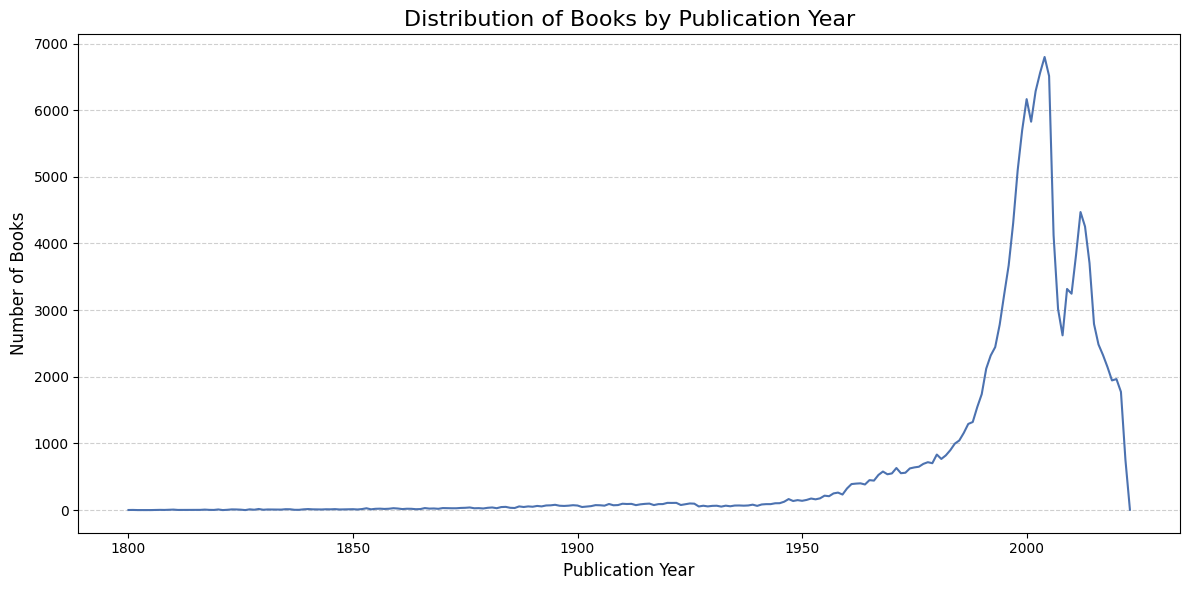

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x="publication_year",
    y="num_books",
    data=books_by_year_pd,
    color="#4C72B0"
)

plt.title("Distribution of Books by Publication Year", fontsize=16)
plt.xlabel("Publication Year", fontsize=12)
plt.ylabel("Number of Books", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Textual EDA

In [ ]:
ratings_text = ratings_df.withColumn(
    "review_text_clean",
    lower(
        regexp_replace(col("review/text"), "[^a-zA-Z\\s]", "")
    )
)
tokenizer = Tokenizer(
    inputCol="review_text_clean",
    outputCol="tokens"
)

ratings_text = tokenizer.transform(ratings_text)

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="tokens_no_stop"
)

ratings_text = remover.transform(ratings_text)



words_df = (
    ratings_text
    .select(explode(col("tokens_no_stop")).alias("word"))
    .filter(col("word") != "")
)
domain_stopwords = ["book", "books", "read", "reading"]
words_df = words_df.filter(~col("word").isin(domain_stopwords))


word_freq = (
    words_df
    .groupBy("word")
    .count()
    .orderBy(col("count").desc())
)


top_words = word_freq.limit(20)
top_words.show(truncate=False)
top_words_pd = top_words.toPandas()



+------+------+
|word  |count |
+------+------+
|one   |191421|
|like  |126407|
|good  |111246|
|great |110611|
|story |106192|
|many  |93434 |
|time  |93019 |
|well  |86801 |
|first |86008 |
|life  |83469 |
|also  |82487 |
|much  |81297 |
|really|80137 |
|love  |73254 |
|get   |72434 |
|people|70367 |
|even  |68933 |
|way   |68383 |
|author|63207 |
|new   |60436 |
+------+------+



/tmp/ipython-input-699734292.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


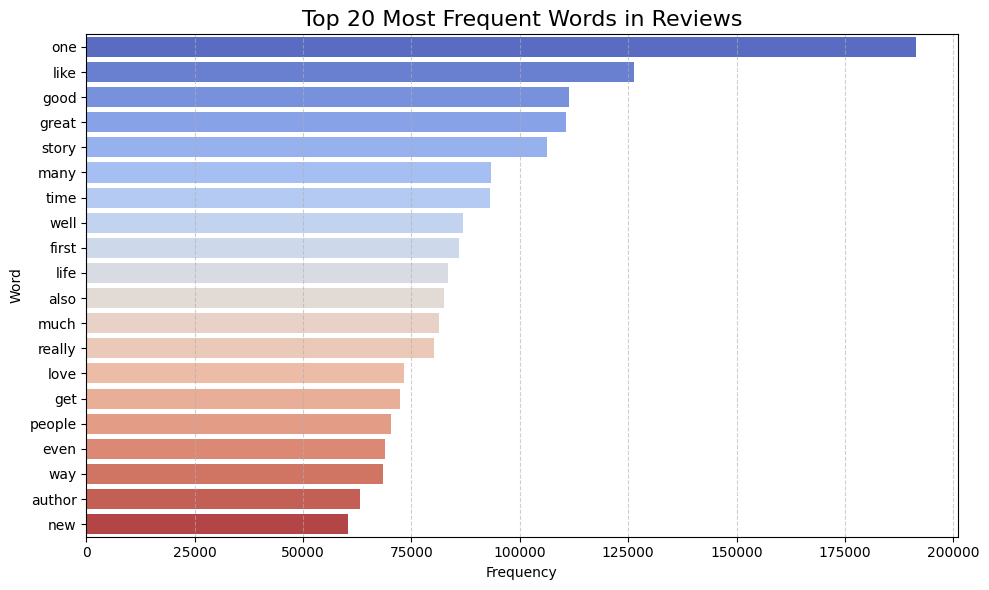

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="count",
    y="word",
    data=top_words_pd,
    palette="coolwarm"
)

plt.title("Top 20 Most Frequent Words in Reviews", fontsize=16)
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
titles_clean = (
    books_df
    .filter(col("Title").isNotNull())
    .withColumn("title_clean", lower(regexp_replace(col("Title"), "[^a-zA-Z\\s]", " ")))
    .withColumn("title_clean", regexp_replace(col("title_clean"), "\\s+", " "))
)

titles_tokens = titles_clean.withColumn(
    "tokens",
    split(col("title_clean"), " ")
)

remover = StopWordsRemover(inputCol="tokens", outputCol="tokens_no_stop")
titles_tokens = remover.transform(titles_tokens)

words_df = titles_tokens.select(
    explode(col("tokens_no_stop")).alias("word")
)

words_df = words_df.filter(
    (trim(col("word")) != "") & (col("word").rlike("^[a-z]{3,}$"))
)

word_freq = (
    words_df
    .groupBy("word")
    .agg(count("*").alias("count"))
    .orderBy(col("count").desc())
)

top_title_words = word_freq.limit(20)
top_title_words.show(truncate=False)


+--------+-----+
|word    |count|
+--------+-----+
|guide   |7217 |
|book    |6603 |
|series  |5296 |
|edition |5009 |
|life    |4192 |
|history |4005 |
|new     |3776 |
|world   |3656 |
|american|3398 |
|story   |2477 |
|war     |2157 |
|books   |1973 |
|complete|1947 |
|library |1929 |
|stories |1926 |
|america |1900 |
|art     |1777 |
|love    |1748 |
|great   |1711 |
|novel   |1682 |
+--------+-----+



/tmp/ipython-input-158007519.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


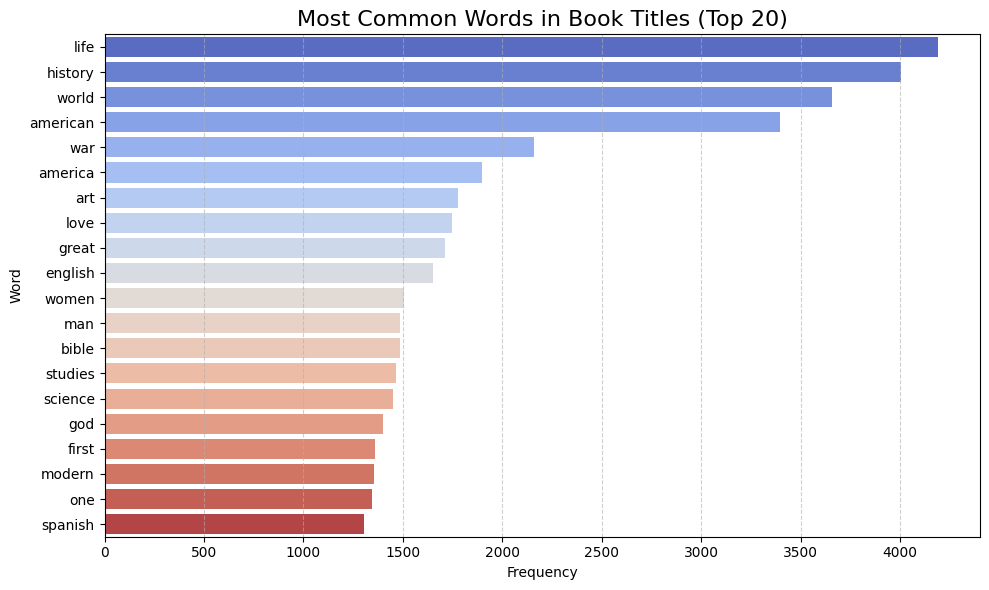

In [ ]:
domain_stop = ["book", "books", "novel", "story", "guide", "edition", "volume", "series", "new", "complete",
               "library", "stories", "handbook", "vol"]
words_df2 = words_df.filter(~col("word").isin(domain_stop))

top_title_words2 = (
    words_df2.groupBy("word").count()
    .orderBy(col("count").desc())
    .limit(20)
)

top_title_words2_pd = top_title_words2.toPandas()

plt.figure(figsize=(10,6))
sns.barplot(
    x="count",
    y="word",
    data=top_title_words2_pd,
    palette="coolwarm"
)

plt.title("Most Common Words in Book Titles (Top 20)", fontsize=16)
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2096939219.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='review_score_num', ylabel='review_length'>

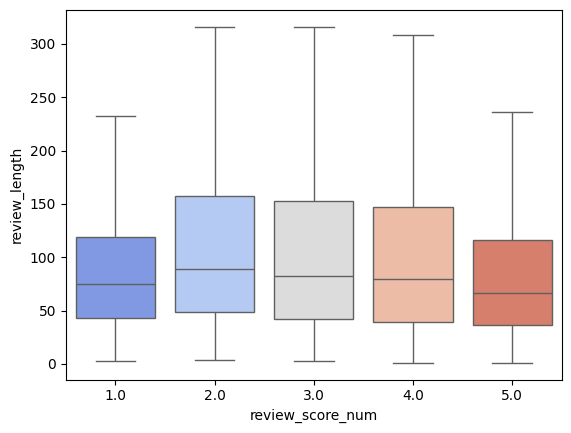

In [ ]:
ratings_text = ratings_df.withColumn(
    "review_length",
    size(split(col("review/text"), " "))
)
# Spark -> Pandas (próbka!)
df_len_pd = ratings_text.select(
    "review_score_num", "review_length"
).sample(fraction=0.02, seed=42).toPandas()

sns.boxplot(
    x="review_score_num",
    y="review_length",
    data=df_len_pd,
    palette="coolwarm",
    showfliers=False
)